<a href="https://colab.research.google.com/github/joolsa/PersonaBase/blob/main/Notebooks/PE04a_Persona_usage_metrics_illustration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Interactive Persona Systems: Behavioral Metrics Analysis
=======================================================

This notebook demonstrates the computation and analysis of behavioral metrics
for interactive persona systems as described in Salminen et al. (2022).

The metrics are divided into two categories:
1. Persona-Based Metrics: Focus on individual persona performance
2. User-Based Metrics: Focus on user behavior patterns

"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random
from collections import Counter, defaultdict
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

print("📊 Interactive Persona Systems - Behavioral Metrics Analysis")
print("=" * 60)

📊 Interactive Persona Systems - Behavioral Metrics Analysis


In [2]:
class PersonaMetricsCalculator:
    """
    A comprehensive class for calculating behavioral metrics in interactive persona systems.

    This class handles both persona-based and user-based metrics computation,
    providing insights into user engagement and persona performance.
    """

    def __init__(self, interaction_data):
        """
        Initialize the calculator with interaction data.

        Parameters:
        -----------
        interaction_data : pd.DataFrame
            DataFrame containing user interaction data with columns:
            - user_id: Unique identifier for users
            - persona_id: Unique identifier for personas
            - session_id: Unique identifier for sessions
            - start_time: Interaction start timestamp
            - end_time: Interaction end timestamp
            - duration: Interaction duration in seconds
        """
        self.data = interaction_data.copy()

        # Validate data BEFORE trying to convert datetime columns
        self._validate_data()

        # Only convert datetime columns if validation passes
        self.data['start_time'] = pd.to_datetime(self.data['start_time'])
        self.data['end_time'] = pd.to_datetime(self.data['end_time'])

        # Precompute useful aggregations
        self.total_personas = self.data['persona_id'].nunique()
        self.total_users = self.data['user_id'].nunique()

        print(f"✅ Initialized with {len(self.data)} interactions")
        print(f"   Users: {self.total_users}, Personas: {self.total_personas}")

    def _validate_data(self):
        """Validate the input data structure and content."""
        # Check if data is empty first
        if self.data.empty:
            raise ValueError("Interaction data cannot be empty")

        # Check for required columns
        required_columns = ['user_id', 'persona_id', 'session_id', 'start_time', 'end_time', 'duration']
        missing_columns = [col for col in required_columns if col not in self.data.columns]

        if missing_columns:
            raise ValueError(f"Missing required columns: {missing_columns}")

        # Check for negative durations
        if (self.data['duration'] < 0).any():
            raise ValueError("Duration values cannot be negative")

    # ==================== PERSONA-BASED METRICS ====================

    def time_spent_per_persona(self):
        """
        Calculate total time spent per persona across all users and sessions.

        Returns:
        --------
        pd.Series: Total duration (seconds) for each persona
        """
        return self.data.groupby('persona_id')['duration'].sum().sort_values(ascending=False)

    def visits_per_persona(self):
        """
        Calculate the number of visits (interactions) per persona.

        Returns:
        --------
        pd.Series: Number of visits for each persona
        """
        return self.data['persona_id'].value_counts().sort_values(ascending=False)

    def average_visit_duration_per_persona(self):
        """
        Calculate average visit duration for each persona.

        Returns:
        --------
        pd.Series: Average duration (seconds) per visit for each persona
        """
        return self.data.groupby('persona_id')['duration'].mean().sort_values(ascending=False)

    # ==================== USER-BASED METRICS ====================

    def personas_visited_per_user(self):
        """
        Calculate the number of distinct personas visited by each user.

        Returns:
        --------
        pd.Series: Number of distinct personas visited per user
        """
        return self.data.groupby('user_id')['persona_id'].nunique().sort_values(ascending=False)

    def persona_coverage_per_user(self):
        """
        Calculate persona coverage ratio for each user.

        Coverage = (Personas visited by user) / (Total available personas)

        Returns:
        --------
        pd.Series: Coverage ratio (0-1) for each user
        """
        personas_per_user = self.personas_visited_per_user()
        return (personas_per_user / self.total_personas).sort_values(ascending=False)

    def persona_sequences_per_session(self):
        """
        Extract persona visit sequences for each session.

        Returns:
        --------
        dict: Session ID -> list of persona IDs in visit order
        """
        sequences = {}

        for session_id in self.data['session_id'].unique():
            session_data = self.data[self.data['session_id'] == session_id]
            # Sort by start time to get visit order
            session_data = session_data.sort_values('start_time')
            sequences[session_id] = session_data['persona_id'].tolist()

        return sequences

    def persona_bigrams(self):
        """
        Calculate frequency of persona bigrams (consecutive pairs) across all sessions.

        Returns:
        --------
        Counter: Frequency count of persona pairs
        """
        sequences = self.persona_sequences_per_session()
        bigrams = Counter()

        for session_id, sequence in sequences.items():
            if len(sequence) >= 2:
                for i in range(len(sequence) - 1):
                    bigram = (sequence[i], sequence[i + 1])
                    bigrams[bigram] += 1

        return bigrams

    def persona_trigrams(self):
        """
        Calculate frequency of persona trigrams (consecutive triplets) across all sessions.

        Returns:
        --------
        Counter: Frequency count of persona triplets
        """
        sequences = self.persona_sequences_per_session()
        trigrams = Counter()

        for session_id, sequence in sequences.items():
            if len(sequence) >= 3:
                for i in range(len(sequence) - 2):
                    trigram = (sequence[i], sequence[i + 1], sequence[i + 2])
                    trigrams[trigram] += 1

        return trigrams

    # ==================== SUMMARY METHODS ====================

    def compute_all_metrics(self):
        """
        Compute all behavioral metrics and return as a comprehensive summary.

        Returns:
        --------
        dict: Dictionary containing all computed metrics
        """
        print("🔄 Computing all behavioral metrics...")

        metrics = {
            'persona_based': {
                'time_spent_per_persona': self.time_spent_per_persona(),
                'visits_per_persona': self.visits_per_persona(),
                'avg_visit_duration_per_persona': self.average_visit_duration_per_persona()
            },
            'user_based': {
                'personas_visited_per_user': self.personas_visited_per_user(),
                'persona_coverage_per_user': self.persona_coverage_per_user(),
                'persona_bigrams': self.persona_bigrams(),
                'persona_trigrams': self.persona_trigrams()
            }
        }

        print("✅ All metrics computed successfully!")
        return metrics

    def summary_statistics(self):
        """
        Generate summary statistics for the interaction data.

        Returns:
        --------
        dict: Summary statistics
        """
        stats = {
            'total_interactions': len(self.data),
            'total_users': self.total_users,
            'total_personas': self.total_personas,
            'total_sessions': self.data['session_id'].nunique(),
            'avg_interactions_per_user': len(self.data) / self.total_users,
            'avg_interactions_per_persona': len(self.data) / self.total_personas,
            'avg_session_length': self.data.groupby('session_id')['duration'].sum().mean(),
            'total_interaction_time': self.data['duration'].sum()
        }
        return stats

In [3]:
def generate_synthetic_persona_data(n_users=100, n_personas=20, n_sessions=300,
                                   start_date='2024-01-01', end_date='2024-12-31'):
    """
    Generate synthetic interaction data for persona systems testing.

    This function creates realistic interaction patterns including:
    - Varying user engagement levels
    - Popular and unpopular personas
    - Different session lengths and patterns
    - Temporal patterns in usage

    Parameters:
    -----------
    n_users : int
        Number of unique users to simulate
    n_personas : int
        Number of available personas
    n_sessions : int
        Total number of sessions to generate
    start_date : str
        Start date for data generation (YYYY-MM-DD)
    end_date : str
        End date for data generation (YYYY-MM-DD)

    Returns:
    --------
    pd.DataFrame: Synthetic interaction data
    """
    print(f"🎲 Generating synthetic data...")
    print(f"   Users: {n_users}, Personas: {n_personas}, Sessions: {n_sessions}")

    # Create date range
    start = datetime.strptime(start_date, '%Y-%m-%d')
    end = datetime.strptime(end_date, '%Y-%m-%d')
    date_range = (end - start).days

    # Create persona popularity distribution (some personas are more popular)
    persona_weights = np.random.zipf(1.5, n_personas)
    persona_weights = persona_weights / persona_weights.sum()

    # Create user engagement levels (some users are more active)
    user_engagement = np.random.exponential(2.0, n_users)

    interactions = []
    interaction_id = 1

    for session_id in range(1, n_sessions + 1):
        # Select user for this session
        user_id = f"user_{random.randint(1, n_users):03d}"
        user_idx = int(user_id.split('_')[1]) - 1

        # Session date
        session_date = start + timedelta(days=random.randint(0, date_range))

        # Number of interactions in this session (influenced by user engagement)
        n_interactions = max(1, int(np.random.poisson(user_engagement[user_idx]) + 1))
        n_interactions = min(n_interactions, 15)  # Cap at 15 interactions per session

        # Select personas for this session
        session_personas = np.random.choice(
            [f"persona_{i:02d}" for i in range(1, n_personas + 1)],
            size=n_interactions,
            p=persona_weights,
            replace=True
        )

        # Generate interactions for this session
        current_time = session_date

        for i, persona_id in enumerate(session_personas):
            # Duration influenced by persona popularity and user engagement
            base_duration = 30 + np.random.exponential(120)  # 30s base + exponential
            duration = max(5, int(base_duration * (0.5 + user_engagement[user_idx] / 10)))
            duration = min(duration, 1800)  # Cap at 30 minutes

            start_time = current_time
            end_time = start_time + timedelta(seconds=duration)

            interactions.append({
                'interaction_id': interaction_id,
                'user_id': user_id,
                'persona_id': persona_id,
                'session_id': f"session_{session_id:04d}",
                'start_time': start_time,
                'end_time': end_time,
                'duration': duration
            })

            interaction_id += 1

            # Add some time between interactions (break)
            current_time = end_time + timedelta(seconds=random.randint(5, 60))

    df = pd.DataFrame(interactions)
    print(f"✅ Generated {len(df)} interactions")
    return df

# Generate synthetic data
print("=" * 60)
synthetic_data = generate_synthetic_persona_data(
    n_users=150,
    n_personas=25,
    n_sessions=500
)

# Display sample data
print("\n📋 Sample of generated data:")
print(synthetic_data.head(10))

🎲 Generating synthetic data...
   Users: 150, Personas: 25, Sessions: 500
✅ Generated 1392 interactions

📋 Sample of generated data:
   interaction_id   user_id  persona_id    session_id          start_time  \
0               1  user_029  persona_24  session_0001 2024-01-13 00:00:00   
1               2  user_029  persona_16  session_0001 2024-01-13 00:02:56   
2               3  user_029  persona_25  session_0001 2024-01-13 00:05:00   
3               4  user_058  persona_25  session_0002 2024-03-12 00:00:00   
4               5  user_058  persona_16  session_0002 2024-03-12 00:02:38   
5               6  user_058  persona_25  session_0002 2024-03-12 00:03:42   
6               7  user_058  persona_12  session_0002 2024-03-12 00:07:25   
7               8  user_058  persona_15  session_0002 2024-03-12 00:09:23   
8               9  user_023  persona_01  session_0003 2024-10-29 00:00:00   
9              10  user_023  persona_25  session_0003 2024-10-29 00:01:26   

             end_ti

In [4]:
# Initialize the metrics calculator
print("\n" + "=" * 60)
calculator = PersonaMetricsCalculator(synthetic_data)

# Compute summary statistics
print("\n📊 Dataset Summary Statistics:")
stats = calculator.summary_statistics()
for key, value in stats.items():
    if isinstance(value, float):
        print(f"   {key.replace('_', ' ').title()}: {value:.2f}")
    else:
        print(f"   {key.replace('_', ' ').title()}: {value}")


✅ Initialized with 1392 interactions
   Users: 147, Personas: 25

📊 Dataset Summary Statistics:
   Total Interactions: 1392
   Total Users: 147
   Total Personas: 25
   Total Sessions: 500
   Avg Interactions Per User: 9.47
   Avg Interactions Per Persona: 55.68
   Avg Session Length: 310.16
   Total Interaction Time: 155080


In [5]:
# Compute all metrics
print("\n" + "=" * 60)
all_metrics = calculator.compute_all_metrics()

# Display Persona-Based Metrics
print("\n🎭 PERSONA-BASED METRICS")
print("-" * 40)

print("\n1. Time Spent per Persona (Top 10):")
time_spent = all_metrics['persona_based']['time_spent_per_persona']
for persona, time_sec in time_spent.head(10).items():
    time_min = time_sec / 60
    print(f"   {persona}: {time_min:.1f} minutes ({time_sec:.0f}s)")

print(f"\n2. Number of Visits per Persona (Top 10):")
visits = all_metrics['persona_based']['visits_per_persona']
for persona, count in visits.head(10).items():
    print(f"   {persona}: {count} visits")

print(f"\n3. Average Visit Duration per Persona (Top 10):")
avg_duration = all_metrics['persona_based']['avg_visit_duration_per_persona']
for persona, duration in avg_duration.head(10).items():
    print(f"   {persona}: {duration:.1f} seconds")


🔄 Computing all behavioral metrics...
✅ All metrics computed successfully!

🎭 PERSONA-BASED METRICS
----------------------------------------

1. Time Spent per Persona (Top 10):
   persona_25: 638.8 minutes (38327s)
   persona_05: 598.7 minutes (35924s)
   persona_01: 327.2 minutes (19631s)
   persona_16: 200.3 minutes (12019s)
   persona_13: 107.1 minutes (6426s)
   persona_09: 99.5 minutes (5970s)
   persona_12: 90.4 minutes (5426s)
   persona_08: 64.4 minutes (3865s)
   persona_21: 63.5 minutes (3808s)
   persona_15: 62.8 minutes (3765s)

2. Number of Visits per Persona (Top 10):
   persona_25: 347 visits
   persona_05: 336 visits
   persona_01: 154 visits
   persona_16: 114 visits
   persona_09: 56 visits
   persona_13: 56 visits
   persona_12: 56 visits
   persona_21: 35 visits
   persona_08: 34 visits
   persona_15: 26 visits

3. Average Visit Duration per Persona (Top 10):
   persona_23: 154.2 seconds
   persona_22: 149.7 seconds
   persona_18: 148.5 seconds
   persona_15: 144.

In [6]:
# Display User-Based Metrics
print("\n👥 USER-BASED METRICS")
print("-" * 40)

print("\n1. Number of Personas Visited per User (Top 10):")
personas_visited = all_metrics['user_based']['personas_visited_per_user']
for user, count in personas_visited.head(10).items():
    print(f"   {user}: {count} personas")

print(f"\n2. Persona Coverage per User (Top 10):")
coverage = all_metrics['user_based']['persona_coverage_per_user']
for user, ratio in coverage.head(10).items():
    print(f"   {user}: {ratio:.2%} coverage")

print(f"\n3. Most Common Persona Bigrams (Top 10):")
bigrams = all_metrics['user_based']['persona_bigrams']
for bigram, count in bigrams.most_common(10):
    print(f"   {bigram[0]} → {bigram[1]}: {count} times")

print(f"\n4. Most Common Persona Trigrams (Top 5):")
trigrams = all_metrics['user_based']['persona_trigrams']
for trigram, count in trigrams.most_common(5):
    print(f"   {trigram[0]} → {trigram[1]} → {trigram[2]}: {count} times")


👥 USER-BASED METRICS
----------------------------------------

1. Number of Personas Visited per User (Top 10):
   user_058: 15 personas
   user_140: 14 personas
   user_136: 13 personas
   user_084: 12 personas
   user_087: 12 personas
   user_041: 11 personas
   user_076: 11 personas
   user_050: 10 personas
   user_120: 10 personas
   user_128: 10 personas

2. Persona Coverage per User (Top 10):
   user_058: 60.00% coverage
   user_140: 56.00% coverage
   user_136: 52.00% coverage
   user_084: 48.00% coverage
   user_087: 48.00% coverage
   user_041: 44.00% coverage
   user_076: 44.00% coverage
   user_050: 40.00% coverage
   user_120: 40.00% coverage
   user_128: 40.00% coverage

3. Most Common Persona Bigrams (Top 10):
   persona_25 → persona_25: 57 times
   persona_25 → persona_05: 53 times
   persona_05 → persona_25: 51 times
   persona_05 → persona_05: 47 times
   persona_01 → persona_05: 26 times
   persona_16 → persona_25: 24 times
   persona_05 → persona_01: 24 times
   per


📈 Creating comprehensive visualizations...


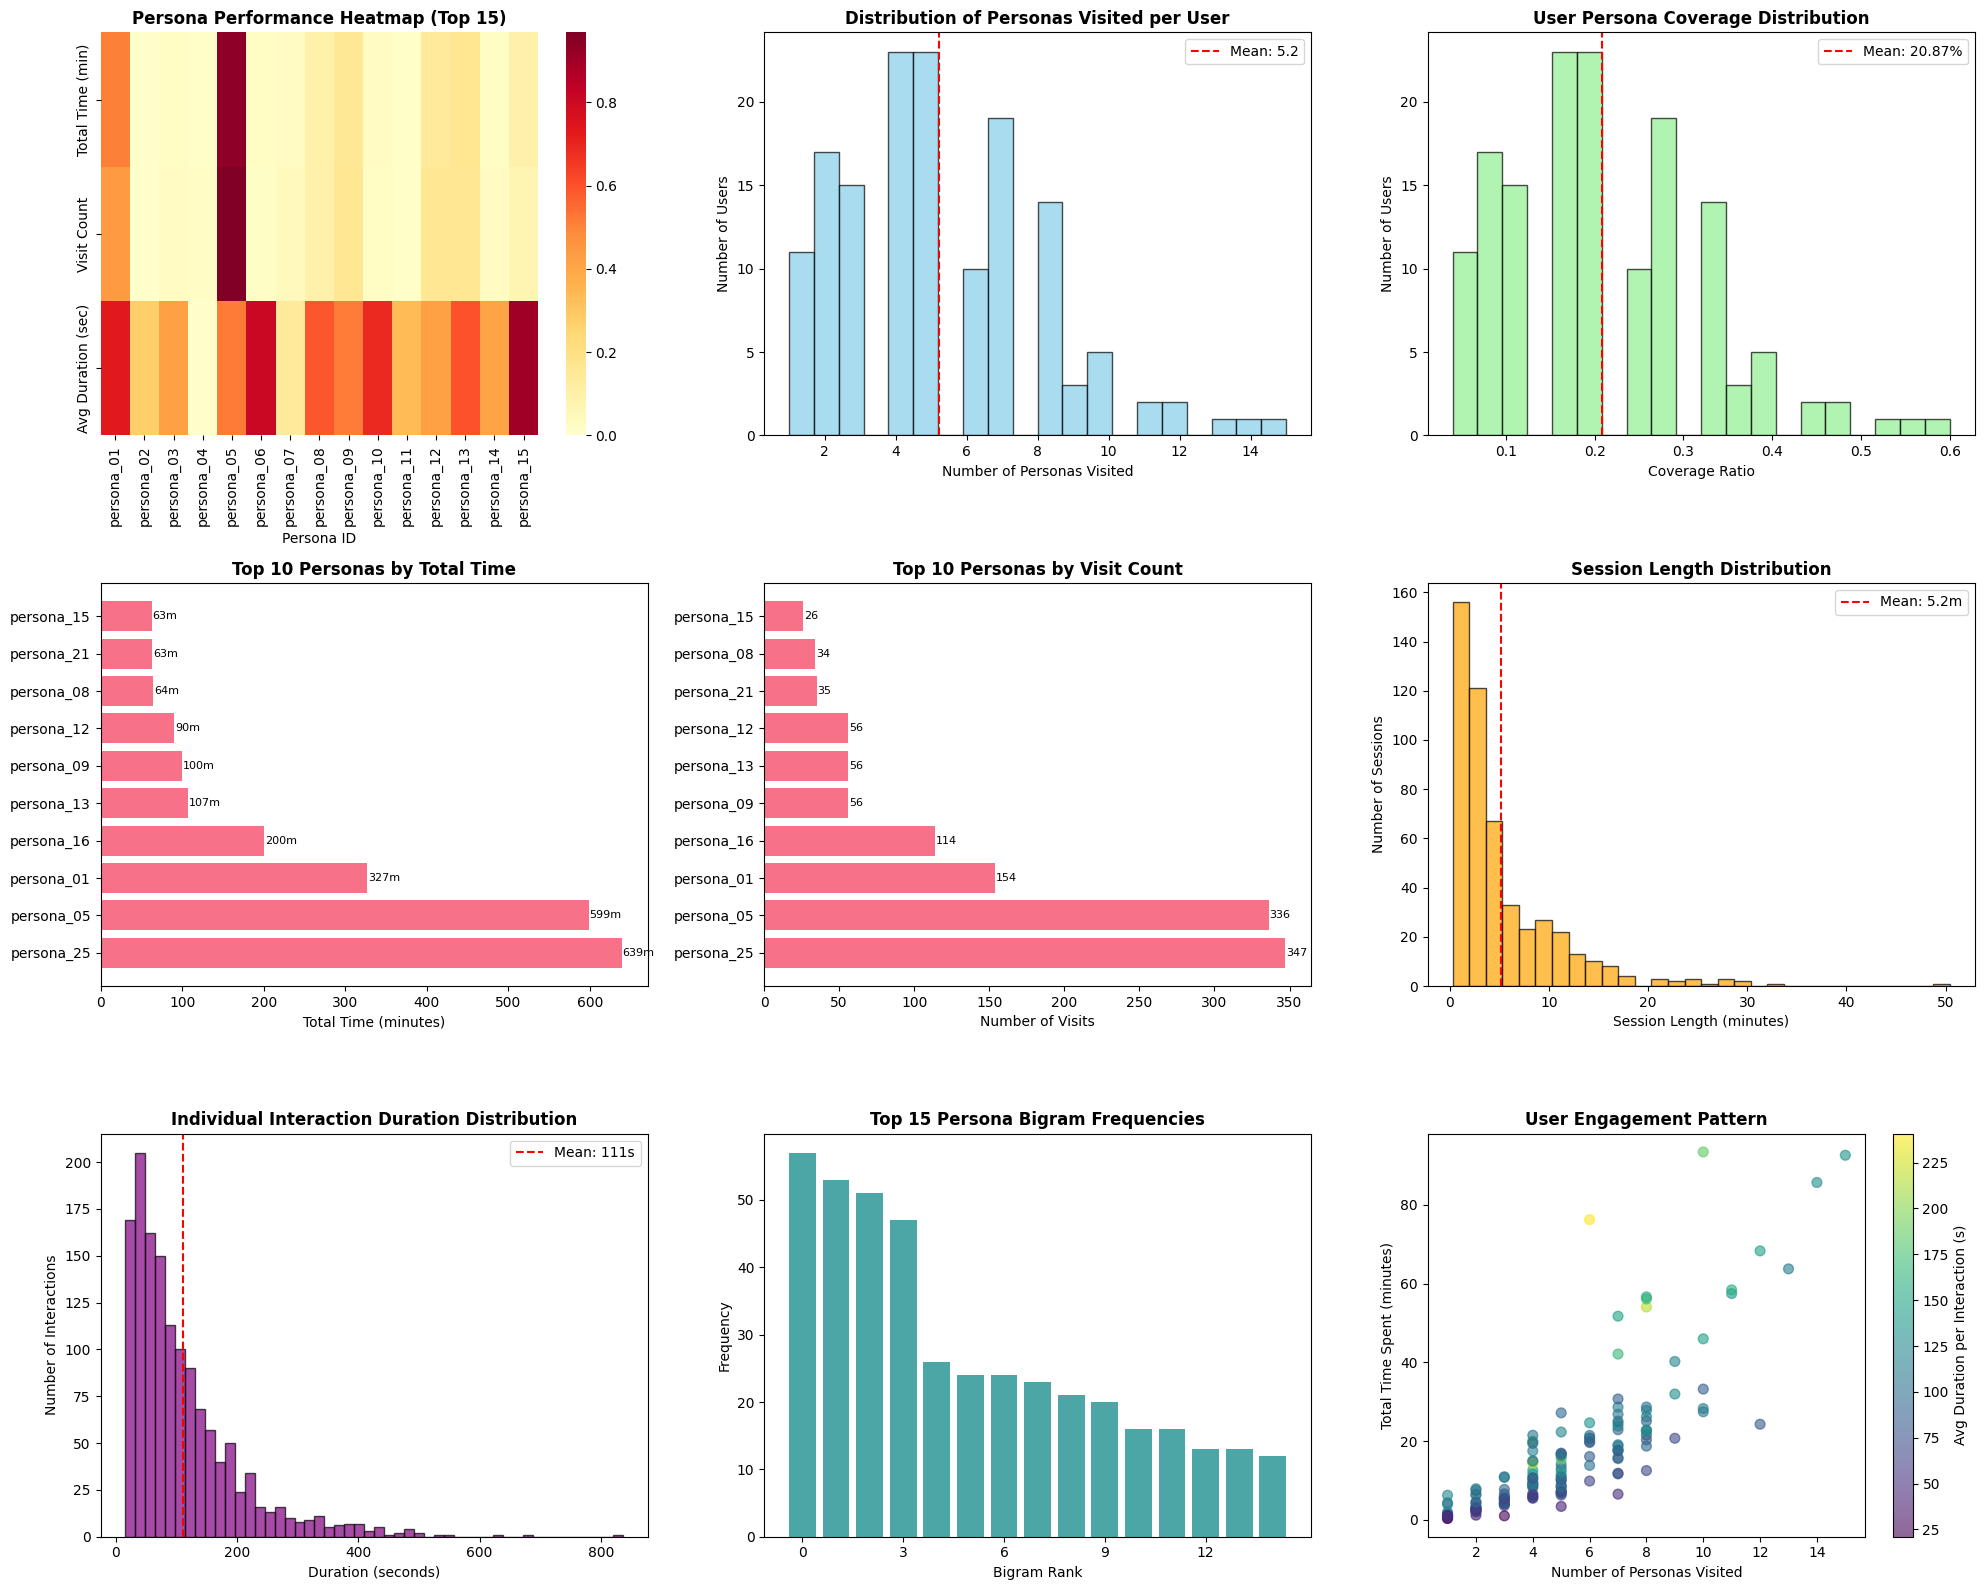

In [7]:
def create_visualizations(calculator, metrics):
    """
    Create comprehensive visualizations for persona behavioral metrics.

    Parameters:
    -----------
    calculator : PersonaMetricsCalculator
        The metrics calculator instance
    metrics : dict
        Dictionary containing all computed metrics
    """

    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")

    # Create a large figure with multiple subplots
    fig = plt.figure(figsize=(20, 16))

    # 1. Persona Performance Heatmap
    ax1 = plt.subplot(3, 3, 1)

    # Combine persona metrics into a dataframe for heatmap
    persona_df = pd.DataFrame({
        'Total Time (min)': metrics['persona_based']['time_spent_per_persona'] / 60,
        'Visit Count': metrics['persona_based']['visits_per_persona'],
        'Avg Duration (sec)': metrics['persona_based']['avg_visit_duration_per_persona']
    }).fillna(0)

    # Normalize for better visualization
    persona_df_norm = persona_df.apply(lambda x: (x - x.min()) / (x.max() - x.min()))

    sns.heatmap(persona_df_norm.head(15).T, annot=False, cmap='YlOrRd', ax=ax1)
    ax1.set_title('Persona Performance Heatmap (Top 15)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Persona ID')

    # 2. Distribution of User Engagement
    ax2 = plt.subplot(3, 3, 2)
    user_personas = metrics['user_based']['personas_visited_per_user']
    ax2.hist(user_personas, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    ax2.set_title('Distribution of Personas Visited per User', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Number of Personas Visited')
    ax2.set_ylabel('Number of Users')
    ax2.axvline(user_personas.mean(), color='red', linestyle='--',
                label=f'Mean: {user_personas.mean():.1f}')
    ax2.legend()

    # 3. Persona Coverage Distribution
    ax3 = plt.subplot(3, 3, 3)
    coverage = metrics['user_based']['persona_coverage_per_user']
    ax3.hist(coverage, bins=20, alpha=0.7, color='lightgreen', edgecolor='black')
    ax3.set_title('User Persona Coverage Distribution', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Coverage Ratio')
    ax3.set_ylabel('Number of Users')
    ax3.axvline(coverage.mean(), color='red', linestyle='--',
                label=f'Mean: {coverage.mean():.2%}')
    ax3.legend()

    # 4. Top Personas by Total Time
    ax4 = plt.subplot(3, 3, 4)
    top_time = metrics['persona_based']['time_spent_per_persona'].head(10)
    bars4 = ax4.barh(range(len(top_time)), top_time.values / 60)
    ax4.set_yticks(range(len(top_time)))
    ax4.set_yticklabels(top_time.index)
    ax4.set_title('Top 10 Personas by Total Time', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Total Time (minutes)')

    # Add value labels on bars
    for i, bar in enumerate(bars4):
        width = bar.get_width()
        ax4.text(width + 1, bar.get_y() + bar.get_height()/2,
                f'{width:.0f}m', ha='left', va='center', fontsize=8)

    # 5. Top Personas by Visit Count
    ax5 = plt.subplot(3, 3, 5)
    top_visits = metrics['persona_based']['visits_per_persona'].head(10)
    bars5 = ax5.barh(range(len(top_visits)), top_visits.values)
    ax5.set_yticks(range(len(top_visits)))
    ax5.set_yticklabels(top_visits.index)
    ax5.set_title('Top 10 Personas by Visit Count', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Number of Visits')

    # Add value labels on bars
    for i, bar in enumerate(bars5):
        width = bar.get_width()
        ax5.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                f'{int(width)}', ha='left', va='center', fontsize=8)

    # 6. Session Length Distribution
    ax6 = plt.subplot(3, 3, 6)
    session_lengths = calculator.data.groupby('session_id')['duration'].sum() / 60  # Convert to minutes
    ax6.hist(session_lengths, bins=30, alpha=0.7, color='orange', edgecolor='black')
    ax6.set_title('Session Length Distribution', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Session Length (minutes)')
    ax6.set_ylabel('Number of Sessions')
    ax6.axvline(session_lengths.mean(), color='red', linestyle='--',
                label=f'Mean: {session_lengths.mean():.1f}m')
    ax6.legend()

    # 7. Interaction Duration Distribution
    ax7 = plt.subplot(3, 3, 7)
    durations = calculator.data['duration']
    ax7.hist(durations, bins=50, alpha=0.7, color='purple', edgecolor='black')
    ax7.set_title('Individual Interaction Duration Distribution', fontsize=12, fontweight='bold')
    ax7.set_xlabel('Duration (seconds)')
    ax7.set_ylabel('Number of Interactions')
    ax7.axvline(durations.mean(), color='red', linestyle='--',
                label=f'Mean: {durations.mean():.0f}s')
    ax7.legend()

    # 8. Most Common Bigrams Network-style Visualization
    ax8 = plt.subplot(3, 3, 8)
    top_bigrams = dict(metrics['user_based']['persona_bigrams'].most_common(15))

    # Create a simple network visualization
    bigram_df = pd.DataFrame([
        {'from': bigram[0], 'to': bigram[1], 'weight': count}
        for bigram, count in top_bigrams.items()
    ])

    # Simple visualization of bigram frequencies
    if not bigram_df.empty:
        bigram_counts = bigram_df['weight'].values
        bars8 = ax8.bar(range(len(bigram_counts)), bigram_counts, alpha=0.7, color='teal')
        ax8.set_title('Top 15 Persona Bigram Frequencies', fontsize=12, fontweight='bold')
        ax8.set_xlabel('Bigram Rank')
        ax8.set_ylabel('Frequency')
        ax8.set_xticks(range(0, len(bigram_counts), 3))

    # 9. User Engagement Scatter Plot
    ax9 = plt.subplot(3, 3, 9)
    user_stats = calculator.data.groupby('user_id').agg({
        'persona_id': 'nunique',
        'duration': ['sum', 'mean']
    }).round(2)
    user_stats.columns = ['personas_visited', 'total_time', 'avg_duration']

    scatter = ax9.scatter(user_stats['personas_visited'], user_stats['total_time'] / 60,
                         c=user_stats['avg_duration'], alpha=0.6, s=50, cmap='viridis')
    ax9.set_title('User Engagement Pattern', fontsize=12, fontweight='bold')
    ax9.set_xlabel('Number of Personas Visited')
    ax9.set_ylabel('Total Time Spent (minutes)')

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax9)
    cbar.set_label('Avg Duration per Interaction (s)')

    plt.tight_layout()
    plt.show()

# Create visualizations
print("\n" + "=" * 60)
print("📈 Creating comprehensive visualizations...")
create_visualizations(calculator, all_metrics)

In [8]:
def test_persona_metrics_calculator():
    """
    Comprehensive test suite for the PersonaMetricsCalculator class.

    Tests various scenarios and edge cases to ensure robustness.
    """

    test_results = []

    # Test 1: Basic functionality with minimal data
    print("\n1. Testing basic functionality...")
    try:
        test_data = pd.DataFrame({
            'user_id': ['user_001', 'user_001', 'user_002'],
            'persona_id': ['persona_01', 'persona_02', 'persona_01'],
            'session_id': ['session_001', 'session_001', 'session_002'],
            'start_time': ['2024-01-01 10:00:00', '2024-01-01 10:05:00', '2024-01-01 11:00:00'],
            'end_time': ['2024-01-01 10:03:00', '2024-01-01 10:08:00', '2024-01-01 11:05:00'],
            'duration': [180, 180, 300]
        })

        test_calc = PersonaMetricsCalculator(test_data)

        # Test persona-based metrics
        time_spent = test_calc.time_spent_per_persona()
        assert time_spent['persona_01'] == 480, f"Expected 480, got {time_spent['persona_01']}"
        assert time_spent['persona_02'] == 180, f"Expected 180, got {time_spent['persona_02']}"

        visits = test_calc.visits_per_persona()
        assert visits['persona_01'] == 2, f"Expected 2, got {visits['persona_01']}"
        assert visits['persona_02'] == 1, f"Expected 1, got {visits['persona_02']}"

        # Test user-based metrics
        personas_visited = test_calc.personas_visited_per_user()
        assert personas_visited['user_001'] == 2, f"Expected 2, got {personas_visited['user_001']}"
        assert personas_visited['user_002'] == 1, f"Expected 1, got {personas_visited['user_002']}"

        test_results.append("✅ Basic functionality test: PASSED")

    except Exception as e:
        test_results.append(f"❌ Basic functionality test: FAILED - {str(e)}")

    # Test 2: Edge case - single interaction
    print("2. Testing single interaction edge case...")
    try:
        single_data = pd.DataFrame({
            'user_id': ['user_001'],
            'persona_id': ['persona_01'],
            'session_id': ['session_001'],
            'start_time': ['2024-01-01 10:00:00'],
            'end_time': ['2024-01-01 10:03:00'],
            'duration': [180]
        })

        single_calc = PersonaMetricsCalculator(single_data)
        bigrams = single_calc.persona_bigrams()
        trigrams = single_calc.persona_trigrams()

        assert len(bigrams) == 0, "Single interaction should produce no bigrams"
        assert len(trigrams) == 0, "Single interaction should produce no trigrams"

        test_results.append("✅ Single interaction test: PASSED")

    except Exception as e:
        test_results.append(f"❌ Single interaction test: FAILED - {str(e)}")

    # Test 3a: Data validation - Empty data
    print("3a. Testing data validation for empty data...")
    try:
        empty_data = pd.DataFrame()

        error_caught = False
        try:
            PersonaMetricsCalculator(empty_data)
        except ValueError as ve:
            if "Interaction data cannot be empty" in str(ve):
                error_caught = True
                test_results.append("✅ Data validation test (empty data): PASSED")
            else:
                test_results.append(f"❌ Data validation test (empty data): FAILED - Wrong error: {str(ve)}")
        except Exception as e:
            test_results.append(f"❌ Data validation test (empty data): FAILED - Unexpected error: {str(e)}")

        if not error_caught:
            test_results.append("❌ Data validation test (empty data): FAILED - Should have raised ValueError")

    except Exception as e:
        test_results.append(f"❌ Data validation test (empty data): FAILED - Setup error: {str(e)}")

    # Test 3b: Data validation - Missing columns
    print("3b. Testing data validation for missing columns...")
    try:
        # Create data with missing required columns
        invalid_data = pd.DataFrame({
            'user_id': ['user_001'],
            'persona_id': ['persona_01']
            # Missing: session_id, start_time, end_time, duration
        })

        error_caught = False
        try:
            PersonaMetricsCalculator(invalid_data)
        except ValueError as ve:
            if "Missing required columns" in str(ve):
                error_caught = True
                test_results.append("✅ Data validation test (missing columns): PASSED")
            else:
                test_results.append(f"❌ Data validation test (missing columns): FAILED - Wrong error: {str(ve)}")
        except Exception as e:
            test_results.append(f"❌ Data validation test (missing columns): FAILED - Unexpected error: {str(e)}")

        if not error_caught:
            test_results.append("❌ Data validation test (missing columns): FAILED - Should have raised ValueError")

    except Exception as e:
        test_results.append(f"❌ Data validation test (missing columns): FAILED - Setup error: {str(e)}")

    # Test 3c: Data validation - Negative durations
    print("3c. Testing data validation for negative durations...")
    try:
        negative_duration_data = pd.DataFrame({
            'user_id': ['user_001'],
            'persona_id': ['persona_01'],
            'session_id': ['session_001'],
            'start_time': ['2024-01-01 10:00:00'],
            'end_time': ['2024-01-01 10:03:00'],
            'duration': [-180]  # Negative duration
        })

        error_caught = False
        try:
            PersonaMetricsCalculator(negative_duration_data)
        except ValueError as ve:
            if "Duration values cannot be negative" in str(ve):
                error_caught = True
                test_results.append("✅ Data validation test (negative duration): PASSED")
            else:
                test_results.append(f"❌ Data validation test (negative duration): FAILED - Wrong error: {str(ve)}")
        except Exception as e:
            test_results.append(f"❌ Data validation test (negative duration): FAILED - Unexpected error: {str(e)}")

        if not error_caught:
            test_results.append("❌ Data validation test (negative duration): FAILED - Should have raised ValueError")

    except Exception as e:
        test_results.append(f"❌ Data validation test (negative duration): FAILED - Setup error: {str(e)}")

    # Test 4: Bigram and Trigram calculation
    print("4. Testing bigram and trigram calculation...")
    try:
        sequence_data = pd.DataFrame({
            'user_id': ['user_001'] * 4,
            'persona_id': ['persona_A', 'persona_B', 'persona_C', 'persona_A'],
            'session_id': ['session_001'] * 4,
            'start_time': ['2024-01-01 10:00:00', '2024-01-01 10:05:00',
                          '2024-01-01 10:10:00', '2024-01-01 10:15:00'],
            'end_time': ['2024-01-01 10:03:00', '2024-01-01 10:08:00',
                        '2024-01-01 10:13:00', '2024-01-01 10:18:00'],
            'duration': [180, 180, 180, 180]
        })

        seq_calc = PersonaMetricsCalculator(sequence_data)
        bigrams = seq_calc.persona_bigrams()
        trigrams = seq_calc.persona_trigrams()

        assert len(bigrams) == 3, f"Expected 3 bigrams, got {len(bigrams)}"
        assert len(trigrams) == 2, f"Expected 2 trigrams, got {len(trigrams)}"

        test_results.append("✅ Bigram/Trigram calculation test: PASSED")

    except Exception as e:
        test_results.append(f"❌ Bigram/Trigram calculation test: FAILED - {str(e)}")

    # Test 5: Coverage calculation
    print("5. Testing coverage calculation...")
    try:
        coverage_data = pd.DataFrame({
            'user_id': ['user_001'] * 3 + ['user_002'] * 2,
            'persona_id': ['persona_01', 'persona_02', 'persona_03', 'persona_01', 'persona_02'],
            'session_id': ['session_001'] * 3 + ['session_002'] * 2,
            'start_time': ['2024-01-01 10:00:00'] * 5,
            'end_time': ['2024-01-01 10:03:00'] * 5,
            'duration': [180] * 5
        })

        cov_calc = PersonaMetricsCalculator(coverage_data)
        coverage = cov_calc.persona_coverage_per_user()

        # Total personas = 3, user_001 visited 3, user_002 visited 2
        assert abs(coverage['user_001'] - 1.0) < 0.01, f"Expected 1.0, got {coverage['user_001']}"
        assert abs(coverage['user_002'] - 2/3) < 0.01, f"Expected 0.67, got {coverage['user_002']}"

        test_results.append("✅ Coverage calculation test: PASSED")

    except Exception as e:
        test_results.append(f"❌ Coverage calculation test: FAILED - {str(e)}")

    return test_results

# Run the tests
print("\n" + "=" * 60)
print("🧪 RUNNING TESTS")
print("-" * 40)

test_results = test_persona_metrics_calculator()

print("\n📋 Test Results Summary:")
for result in test_results:
    print(f"   {result}")

passed_tests = sum(1 for result in test_results if "✅" in result)
total_tests = len(test_results)
print(f"\n🎯 Tests Passed: {passed_tests}/{total_tests} ({passed_tests/total_tests*100:.1f}%)")

if passed_tests == total_tests:
    print("🎉 All tests passed!")
else:
    print("⚠️  Some tests failed. Please review the implementation.")


🧪 RUNNING TESTS
----------------------------------------

1. Testing basic functionality...
✅ Initialized with 3 interactions
   Users: 2, Personas: 2
2. Testing single interaction edge case...
✅ Initialized with 1 interactions
   Users: 1, Personas: 1
3a. Testing data validation for empty data...
3b. Testing data validation for missing columns...
3c. Testing data validation for negative durations...
4. Testing bigram and trigram calculation...
✅ Initialized with 4 interactions
   Users: 1, Personas: 3
5. Testing coverage calculation...
✅ Initialized with 5 interactions
   Users: 2, Personas: 3

📋 Test Results Summary:
   ✅ Basic functionality test: PASSED
   ✅ Single interaction test: PASSED
   ✅ Data validation test (empty data): PASSED
   ✅ Data validation test (missing columns): PASSED
   ✅ Data validation test (negative duration): PASSED
   ✅ Bigram/Trigram calculation test: PASSED
   ✅ Coverage calculation test: PASSED

🎯 Tests Passed: 7/7 (100.0%)
🎉 All tests passed!
